<a href="https://colab.research.google.com/github/dimamagdenko07-spec/python-data-analysis-olist/blob/main/notebooks/python_lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

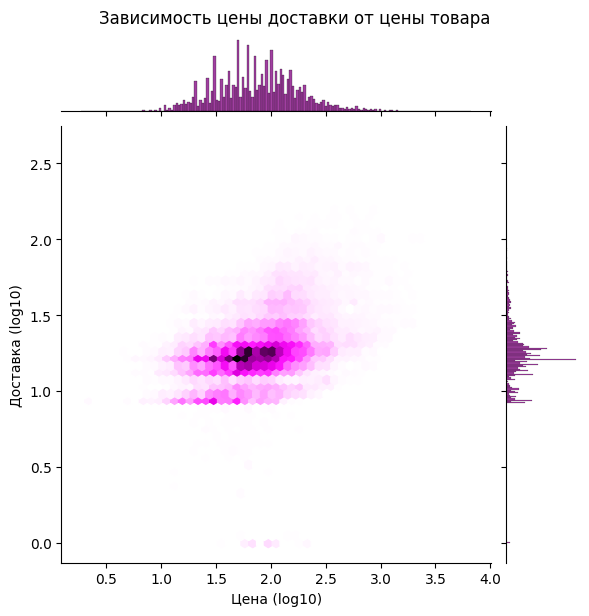

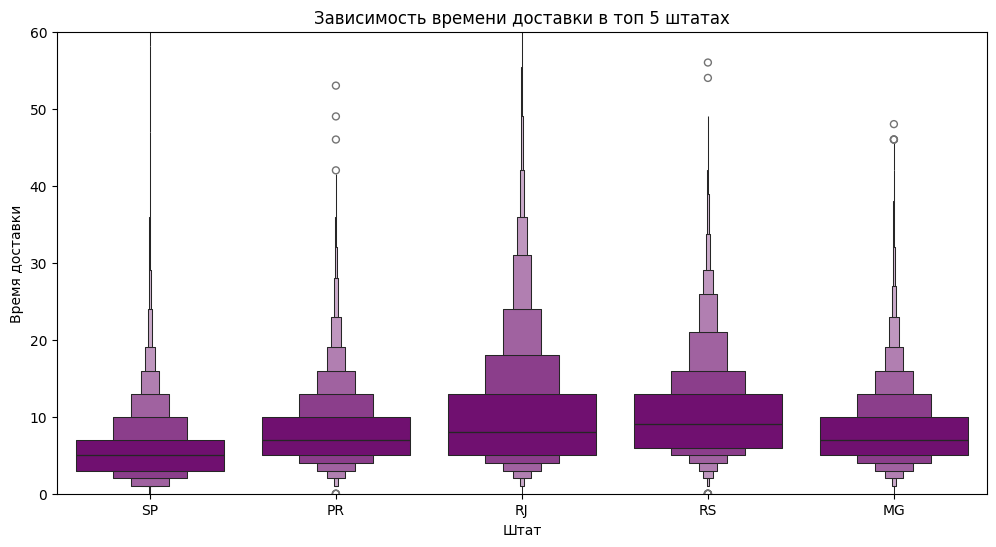

In [ ]:
from numpy import log10
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.gridspec as gridspec
'''Считываем данные'''
cohort_analysis = pd.read_csv('cohort_analysis.csv')
merged = pd.read_csv('merged.csv')
z_score = pd.read_csv('z_score.csv')
table_with_days = pd.read_csv('table_with_days.csv')
intraday = pd.read_csv('intraday_pattern.csv')
days = pd.read_csv("days.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")

'''Производим необходимые махинации с данными и строим гексагональную сетку'''
merged['log_price'] = log10(merged['price']+1)
merged['log_freight_value'] = log10(merged['freight_value']+1)
grafic = sns.jointplot(data=merged, x='log_price', y='log_freight_value', kind='hex', color='purple')
grafic.fig.suptitle('Зависимость цены доставки от цены товара', y=1.02)
grafic.set_axis_labels('Цена (log10)', 'Доставка (log10)')
plt.show()

'''Добавляем в DataFrame отзывы и столбец просрочки'''
merged = merged.merge(reviews, on='order_id', how='left')
merged['is_delayed'] = merged['order_estimated_delivery_date'] < merged['order_delivered_customer_date']
'''Создаём df для штатов и времени доставки'''
top_5_states = merged['customer_state'].value_counts().head(5).index
delivery_states = pd.merge(table_with_days[['customer_id', 'time_days']], merged[['customer_id', 'customer_state']], on = 'customer_id')
delivered_top5 = delivery_states[delivery_states['customer_state'].isin(top_5_states)]
'''Строим boxenplot'''
plt.figure(figsize=(12, 6))
sns.boxenplot(data=delivered_top5, x='customer_state', y='time_days', color='purple')
plt.title("Зависимость времени доставки в топ 5 штатах")
plt.ylim(0, 60)
plt.xlabel('Штат')
plt.ylabel('Время доставки')
plt.show()

Задание 2

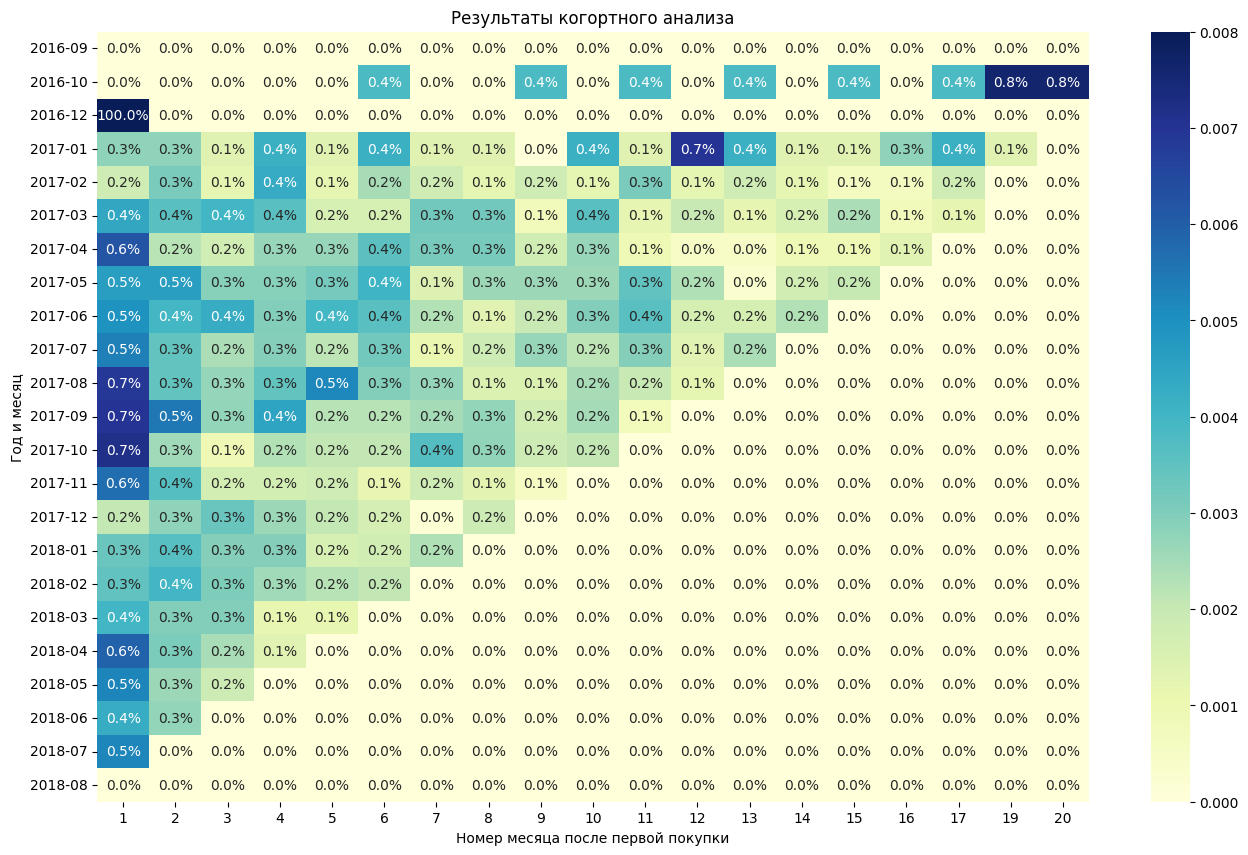

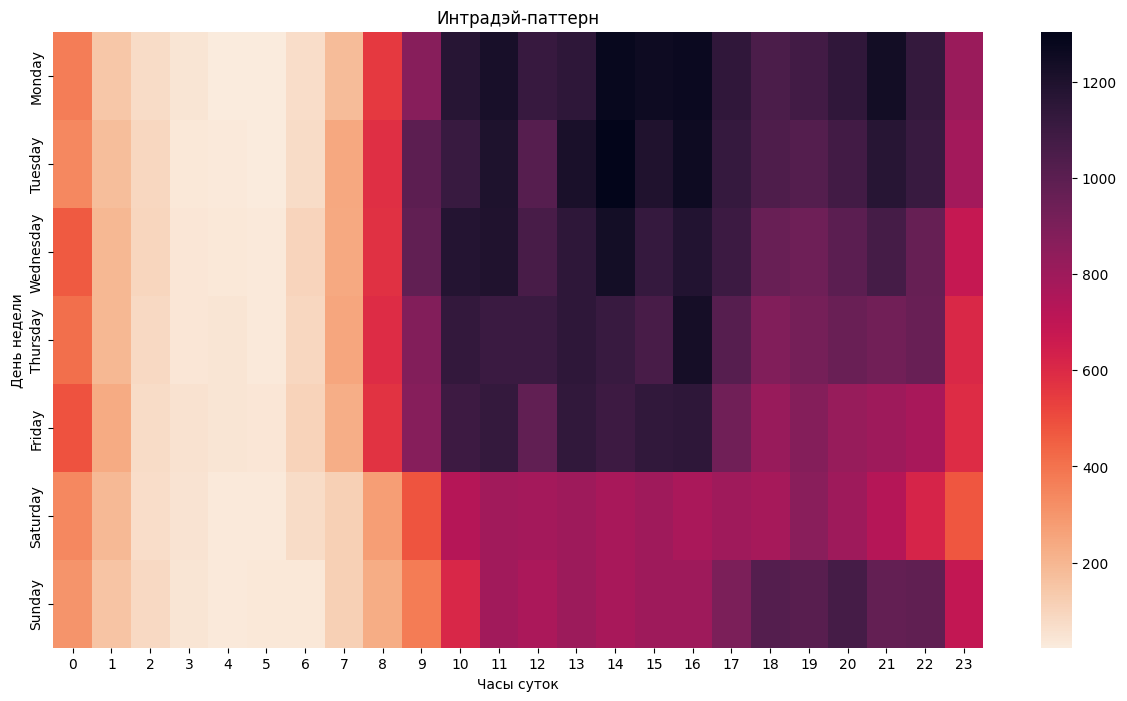

In [ ]:
'''Строим heatmap'''
plt.figure(figsize=(16,10))
cohort_analysis.drop(columns=['0'], inplace=True)
sns.heatmap(
    data=cohort_analysis.set_index('cohort_month'),
    annot=True,
    fmt='.1%',
    cmap='YlGnBu',
    vmax = 0.008
)
plt.title('Результаты когортного анализа')
plt.xlabel('Номер месяца после первой покупки')
plt.ylabel('Год и месяц')
plt.show()

'''Интрадей-паттерн'''
intraday = intraday.set_index('weekday')
days_of_week = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
intraday = intraday.reindex(days_of_week)
plt.figure(figsize=(15, 8))
sns.heatmap(intraday, cmap='rocket_r', annot=False)
plt.title('Интрадэй-паттерн')
plt.xlabel('Часы суток')
plt.ylabel('День недели')
plt.show()

Задание 3

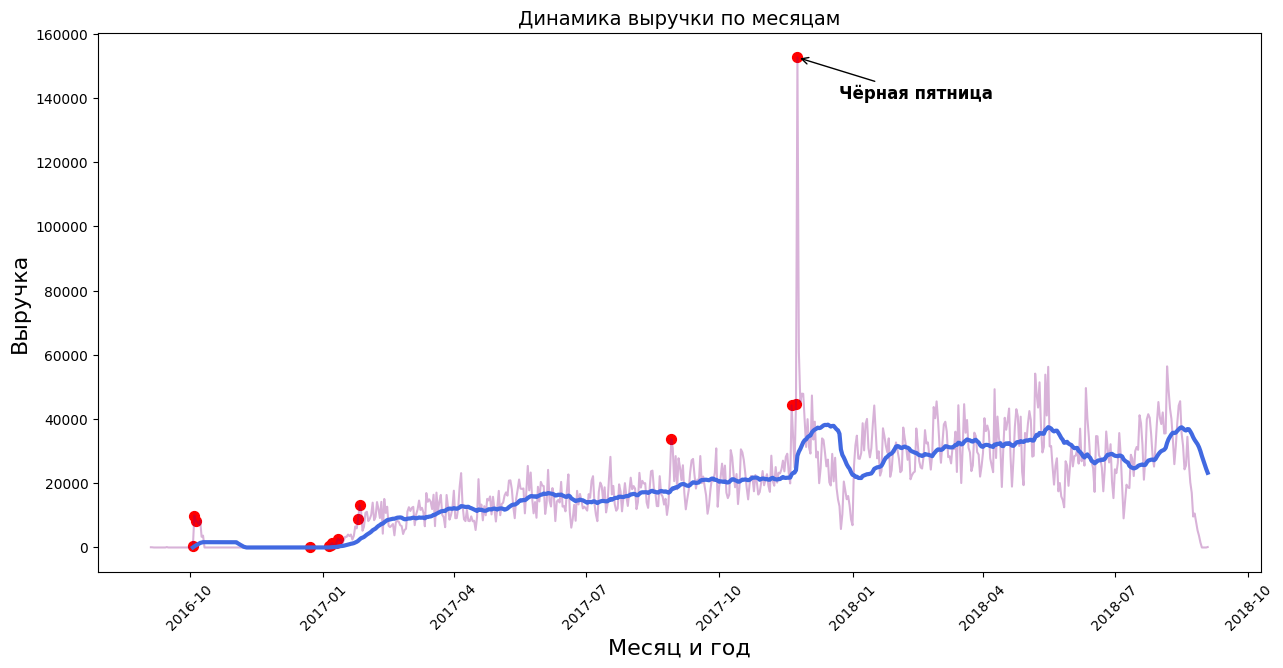

In [ ]:
days['order_purchase_timestamp'] = pd.to_datetime(days['order_purchase_timestamp'])

plt.figure(figsize=(15, 7))
'''Ежедневная выручка'''
plt.plot(days['order_purchase_timestamp'], days['price'], alpha=0.3, color='purple', label='Ежедневная выручка')
'''Скользящее среднее'''
plt.plot(days['order_purchase_timestamp'], days['price'].rolling(30).mean(), color='royalblue', lw=3, label='Скользящее среднее')
'''Аномалии'''
anomalies = days[z_score['price'] > 3].copy()
anomalies['order_purchase_timestamp'] = pd.to_datetime(anomalies['order_purchase_timestamp'])
'''Помечаем аномалии'''
plt.scatter(anomalies['order_purchase_timestamp'], anomalies['price'], color='red', s=50, label= 'Аномалии')
top_anom = anomalies.loc[anomalies['price'].idxmax()]
'''Подписываем самую жёсткую аномалию'''
plt.annotate("Чёрная пятница", xy=(top_anom['order_purchase_timestamp'], top_anom['price']), xytext=(30, -30), textcoords='offset points', arrowprops=dict(arrowstyle='->', color='black'), fontsize=12, fontweight='bold')
plt.title('Динамика выручки по месяцам', fontsize = 14)
plt.xlabel("Месяц и год", fontsize = 16)
plt.ylabel("Выручка", fontsize = 16)
plt.xticks(rotation=45)
plt.show()

Задание 4

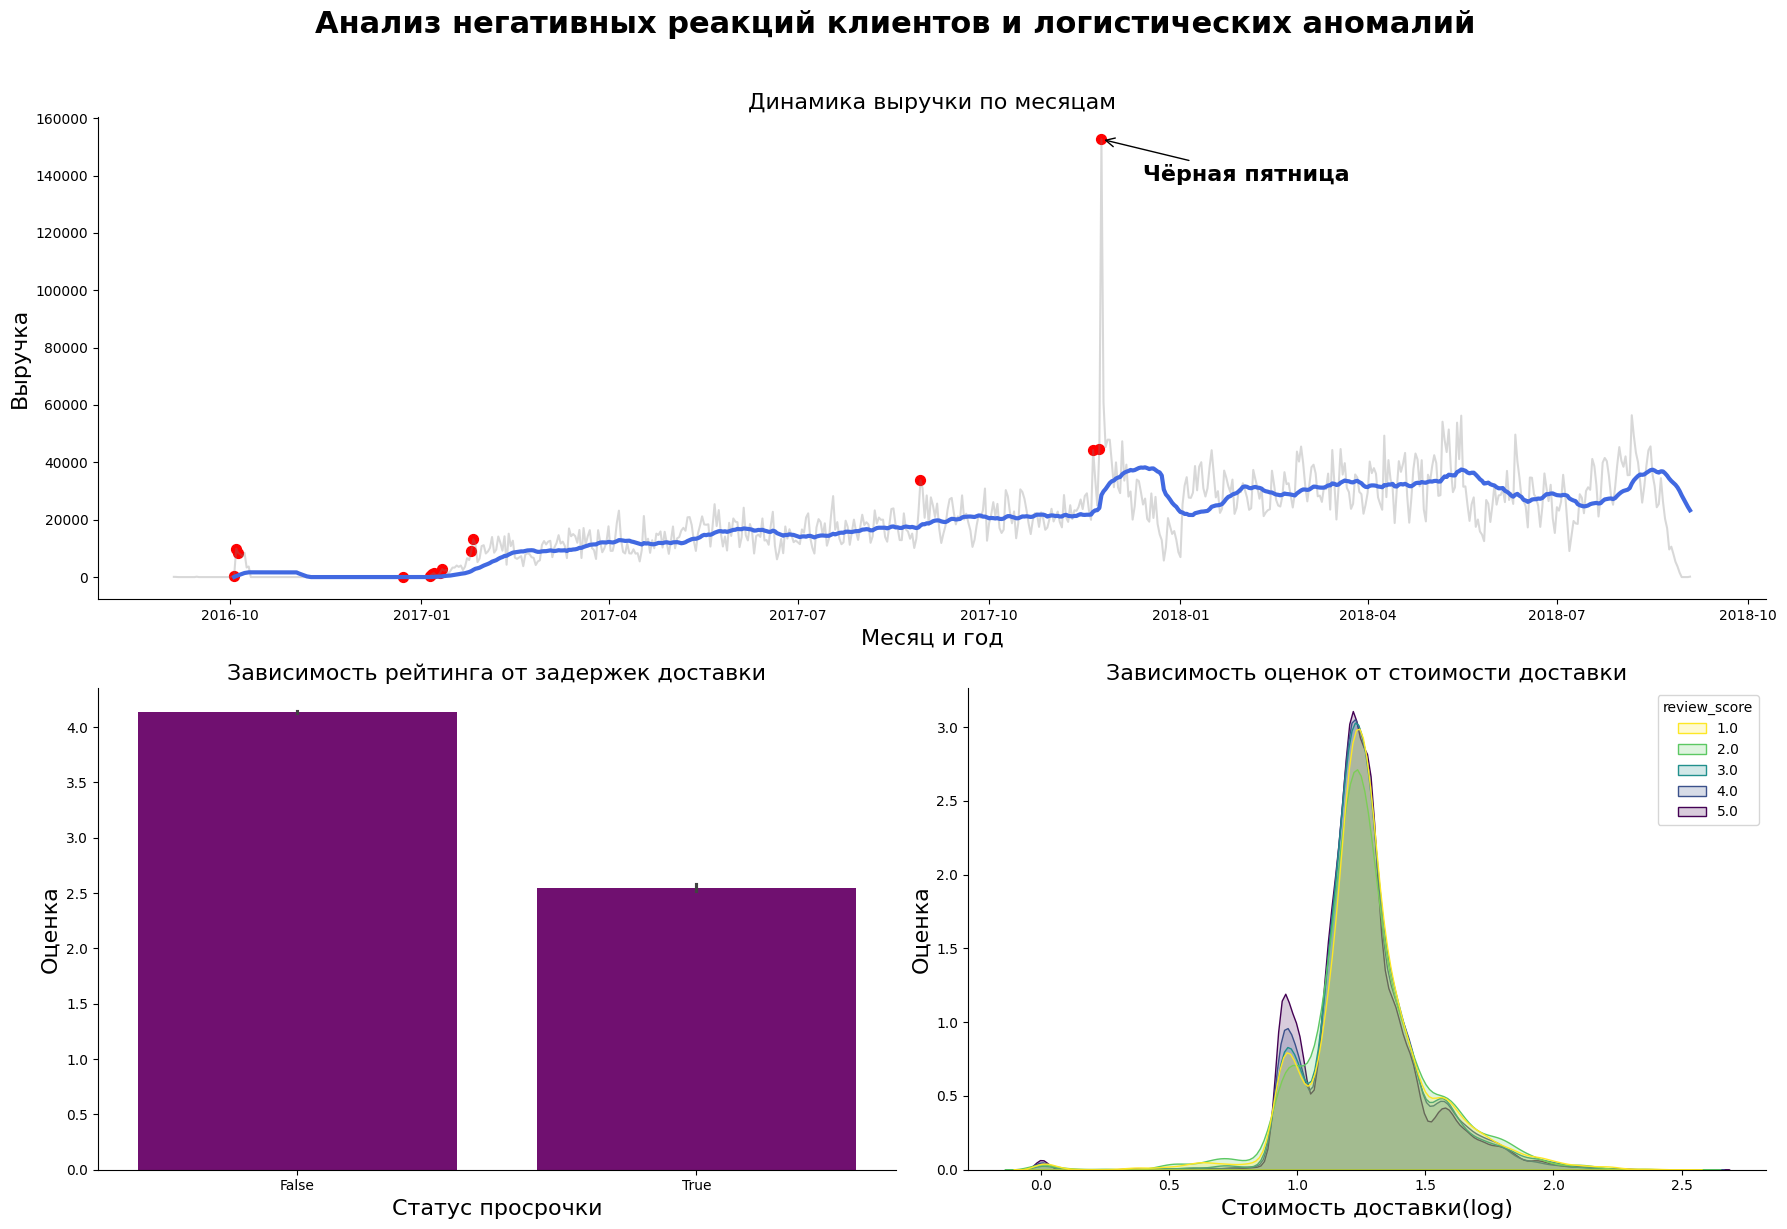

In [ ]:
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, :])
'''Ежедневная выручка'''
ax1.plot(days['order_purchase_timestamp'], days['price'], alpha=0.3, color='gray', label='Ежедневная выручка')
'''Скользящее среднее'''
ax1.plot(days['order_purchase_timestamp'], days['price'].rolling(30).mean(), color='royalblue', lw=3, label='Скользящее среднее')

anomalies = days[z_score['price'] > 3].copy()
ax1.scatter(anomalies['order_purchase_timestamp'], anomalies['price'], color='red', s=50, label= 'Аномалии')
top_anom = anomalies.loc[anomalies['price'].idxmax()]
ax1.annotate("Чёрная пятница", xy=(top_anom['order_purchase_timestamp'], top_anom['price']), xytext=(30, -30), textcoords='offset points', arrowprops=dict(arrowstyle='->', color='black'), fontsize=16, fontweight='bold')
ax1.set_title('Динамика выручки по месяцам', fontsize = 16)
ax1.set_xlabel("Месяц и год", fontsize = 16)
ax1.set_ylabel("Выручка", fontsize = 16)

'''Второй график'''
ax2 = fig.add_subplot(gs[1, 0])
sns.barplot(data=merged, x='is_delayed', y='review_score', ax=ax2, color='purple')
ax2.set_title("Зависимость рейтинга от задержек доставки", fontsize = 16)
ax2.set_xlabel("Статус просрочки", fontsize = 16)
ax2.set_ylabel("Оценка", fontsize = 16)

'''Третий график'''
ax3 = fig.add_subplot(gs[1,1])
sns.kdeplot(
    data=merged,
    x='log_freight_value',
    hue='review_score',
    palette='viridis_r',
    fill=True,
    common_norm=False,
    alpha=0.2,
    ax=ax3
)
ax3.set_title("Зависимость оценок от стоимости доставки", fontsize = 16)
ax3.set_xlabel("Стоимость доставки(log)", fontsize = 16)
ax3.set_ylabel("Оценка", fontsize = 16)

sns.despine()
fig.suptitle('Анализ негативных реакций клиентов и логистических аномалий', fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Гекосогональная сетка говорит о том, что большенство товаров имеют цену от $10^{1.5}$ до $10^2$ денежных единиц с доставкой от $10^{1.2}$ до $10^{1.4}$ денежных единиц.

Boxenplot говорит, что самая долгая и проблемная доставка в штате RJ, но всё равно в целом доставка плюс минус одинаковая по времени.

Результаты когортного анализа говорят, что люди нечасто возвращаются в ближайшие месяца после первой покупки. Из тех кто возвращается, большинство делает повторный заказ на следующем месяце.

Анализ Интрадей паттерн даёт нам понять, что ночью заказы делают очень редко, в будние дни заказы делают чаще всего с 9 до 22 вечера. В субботу люди делают меньше всего заказов. В воскресенье делают заказы с 18 до 22.

Анализ ежедневной выручки даёт понять, что доход с продаж растёт, хоть и медленно. Самый большой скачок в продажах случается на Чёрную Пятницу, что не удивительно.

Последние два графика показывают, что задержка доставки сильно влияет на удовлетворённость покупателей и отзывы. При стоимости доставки около 10 денежных единиц довольных покупаетелй больше, чем недовольных, однако при другой цене и кол-во плохих, и хороших оценок практически идентичное, значит цена доставки не сильно влияет на удовлетворенность клиентов.